In [47]:
import pandas as pd
df = pd.read_csv('/Users/anaghanair/Downloads/youtube-pipeline/data/youtube_clean.csv')

In [48]:
df.head()

,video_id,title,published_at,channel_title,view_count,like_count,comment_count,tags,duration_parsed,time_bucket,is_weekend,engagement_rate,views_per_day,tag_count
0,SixTbTc6YCg,"ice spice, tokischa - thootie",2025-12-05 17:00:06+00:00,IceSpiceVEVO,516179,48825,2663,"['Ice Spice', 'Tokischa', '10K Projects/Capito...",2.550,Afternoon,0,9.458928,516179.0,4
1,VI6XO8EijT4,digital circus ep 7 trailer!!,2025-12-05 20:00:28+00:00,GLITCH,4246050,432146,25506,"['glitch', 'glitch productions', 'digital circ...",0.967,Evening,0,10.177600,4246050.0,19
2,eWPZLDvRebU,5000 days - [hardcore minecraft],2025-12-05 23:00:54+00:00,Luke TheNotable,635604,47461,5484,"['luke thenotable', 'Minecraft', '100 Days', '...",120.017,Night,0,7.467071,635604.0,19
3,FeaRXx2VDhI,top 50 christmas songs of all time 🎄 best chri...,2025-12-05 11:30:23+00:00,Christmas Songs and Carols - Love to Sing,563186,2185,122,"['top christmas song', 'christmas songs', 'top...",139.183,Morning,0,0.387971,563186.0,14
4,IaEtA56pd_w,iron lung: final trailer,2025-12-05 20:48:18+00:00,Markiplier,2084361,325040,16823,"['markiplier', 'iron lung', 'iron lung movie',...",1.750,Evening,0,15.594228,2084361.0,11


In [49]:
df.describe() 

,view_count,like_count,comment_count,duration_parsed,is_weekend,engagement_rate,views_per_day,tag_count
count,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000
mean,4.678255e+05,28074.390000,2304.800000,41.805020,0.240000,5.583995,4.362770e+05,12.620000
std,7.930760e+05,62164.952116,4409.427506,93.090576,0.429235,3.806214,7.900564e+05,10.729719
min,7.778000e+03,129.000000,0.000000,0.350000,0.000000,0.142611,2.964000e+03,1.000000
25%,1.059348e+05,4103.000000,291.500000,2.983000,0.000000,2.258822,8.142931e+04,2.000000
50%,2.148925e+05,9333.000000,709.000000,7.883500,0.000000,5.274571,1.986700e+05,10.000000
75%,5.034872e+05,22200.500000,2187.750000,29.491500,0.000000,7.940032,4.635048e+05,22.000000
max,5.581758e+06,432146.000000,25506.000000,512.700000,1.000000,16.605881,5.581758e+06,40.000000


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         100 non-null    object 
 1   title            100 non-null    object 
 2   published_at     100 non-null    object 
 3   channel_title    100 non-null    object 
 4   view_count       100 non-null    int64  
 5   like_count       100 non-null    int64  
 6   comment_count    100 non-null    int64  
 7   tags             100 non-null    object 
 8   duration_parsed  100 non-null    float64
 9   time_bucket      100 non-null    object 
 10  is_weekend       100 non-null    int64  
 11  engagement_rate  100 non-null    float64
 12  views_per_day    100 non-null    float64
 13  tag_count        100 non-null    int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 11.1+ KB


In [51]:
df.isna().sum()

video_id           0
title              0
published_at       0
channel_title      0
view_count         0
like_count         0
comment_count      0
tags               0
duration_parsed    0
time_bucket        0
is_weekend         0
engagement_rate    0
views_per_day      0
tag_count          0
dtype: int64

In [52]:
df.nunique()

video_id           100
title              100
published_at        99
channel_title      100
view_count         100
like_count         100
comment_count       98
tags                82
duration_parsed     96
time_bucket          5
is_weekend           2
engagement_rate    100
views_per_day      100
tag_count           34
dtype: int64

In [53]:
import matplotlib.pyplot as plt
import numpy as np

In [54]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['view_count', 'like_count', 'comment_count', 'duration_parsed',
        'is_weekend', 'engagement_rate', 'views_per_day', 'tag_count'],
       dtype='object'),
 Index(['video_id', 'title', 'published_at', 'channel_title', 'tags',
        'time_bucket'],
       dtype='object'))

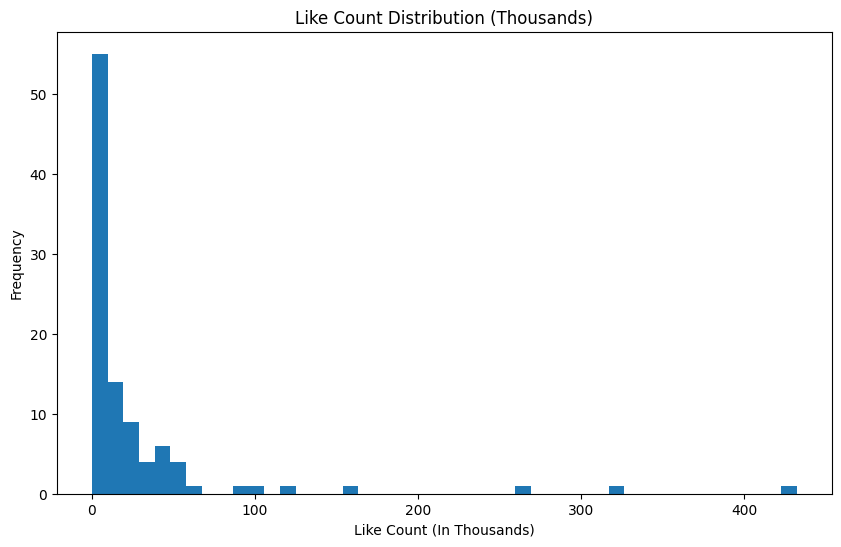

In [55]:
df['like_count_k'] = df['like_count']/1000
df['like_count_k'].plot(kind='hist', bins=45, figsize=(10,6))
plt.title('Like Count Distribution (Thousands)')
plt.xlabel('Like Count (In Thousands)')
plt.ylabel('Frequency')
plt.show()

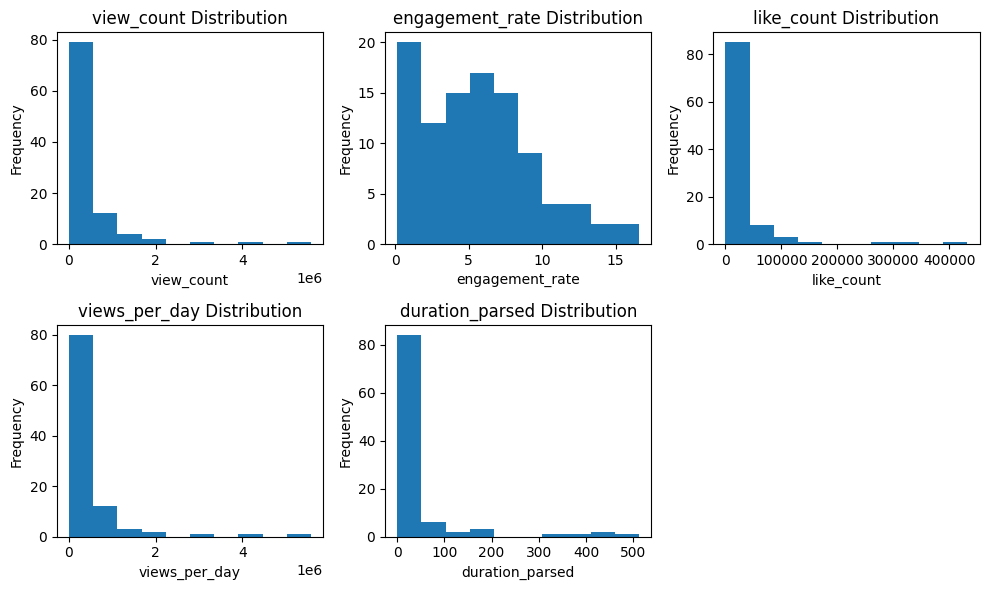

In [56]:
plt.figure(figsize=(10,6))
columns_to_plot = ['view_count', 'engagement_rate', 'like_count', 'views_per_day', 'duration_parsed']
for i,col in enumerate(columns_to_plot,1):
    plt.subplot(2,3,i)
    df[col].plot(kind='hist',bins=10)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



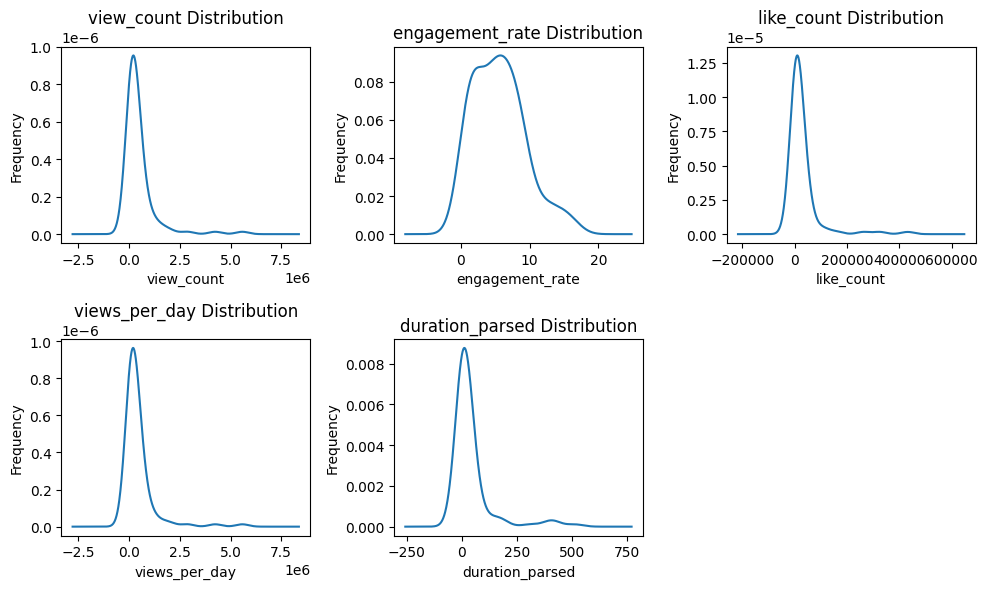

In [57]:
plt.figure(figsize=(10,6))

for i,col in enumerate(columns_to_plot,1):
    plt.subplot(2,3,i)
    df[col].plot(kind='kde')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



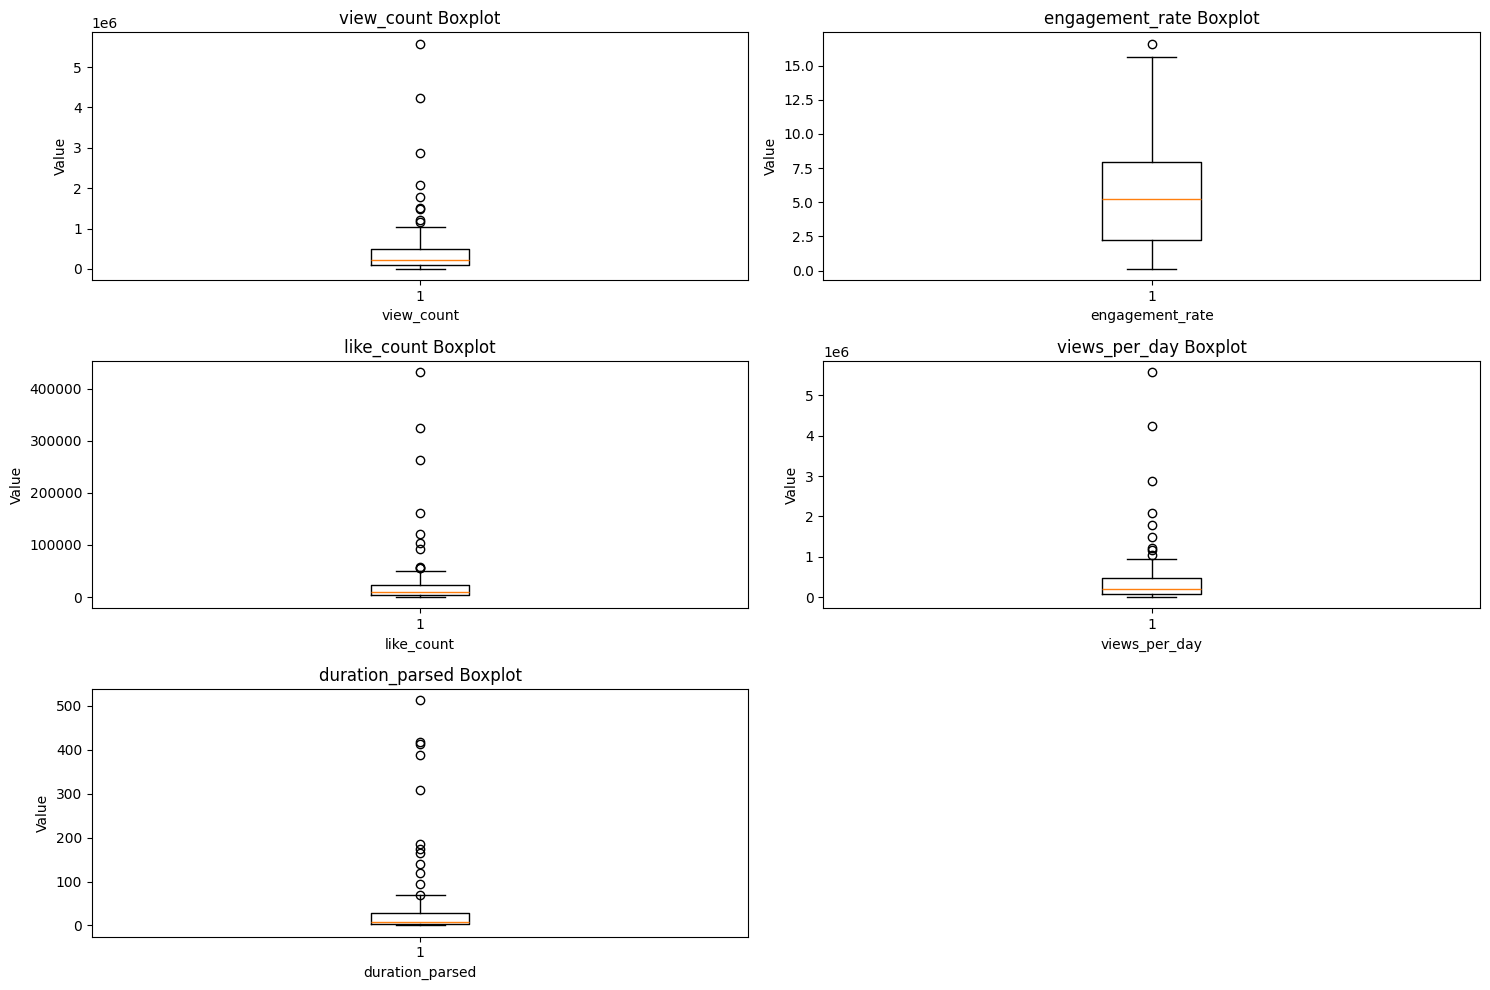

In [58]:
fig = plt.figure(figsize=(15,10))
for i,col in enumerate(columns_to_plot,1):
    ax = fig.add_subplot(3,2,i)
    ax.boxplot(df[col])
    ax.set_title(f"{col} Boxplot")
    ax.set_xlabel(col)
    ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

In [59]:
df.groupby('time_bucket')['view_count'].mean().sort_values(ascending=False)

time_bucket
Evening       1.085102e+06
Night         4.865950e+05
Afternoon     4.684010e+05
Morning       2.188142e+05
Late Night    2.094980e+05
Name: view_count, dtype: float64

In [60]:
df.groupby('time_bucket')['engagement_rate'].mean().sort_values(ascending=False)

time_bucket
Evening       5.967940
Late Night    5.766777
Afternoon     5.522256
Night         5.326941
Morning       5.324196
Name: engagement_rate, dtype: float64

In [61]:
df.groupby('time_bucket')['duration_parsed'].mean().sort_values(ascending=False)

time_bucket
Morning       90.394333
Late Night    54.500038
Afternoon     32.138208
Night         29.836261
Evening       14.747867
Name: duration_parsed, dtype: float64

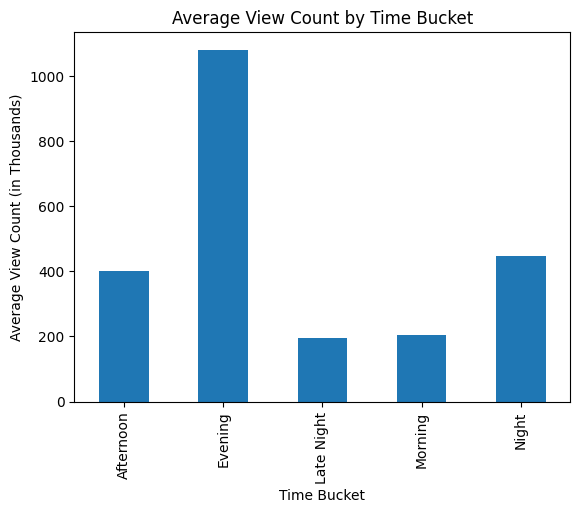

In [62]:
df["views_per_k"] = df["views_per_day"]/1000
df.groupby("time_bucket")["views_per_k"].mean().plot(kind='bar')
plt.title('Average View Count by Time Bucket')
plt.xlabel('Time Bucket')
plt.ylabel('Average View Count (in Thousands)')
plt.show()

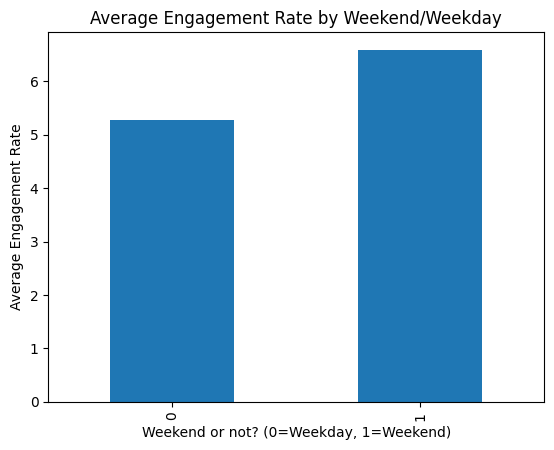

In [63]:
df.groupby("is_weekend")["engagement_rate"].mean().reindex([0,1]).plot(kind="bar")
plt.title('Average Engagement Rate by Weekend/Weekday')
plt.xlabel('Weekend or not? (0=Weekday, 1=Weekend)')
plt.ylabel('Average Engagement Rate')
plt.show()

In [64]:
df.groupby("is_weekend")["views_per_day"].mean().sort_values(ascending=False)


is_weekend
0    513119.520325
1    192942.541667
Name: views_per_day, dtype: float64

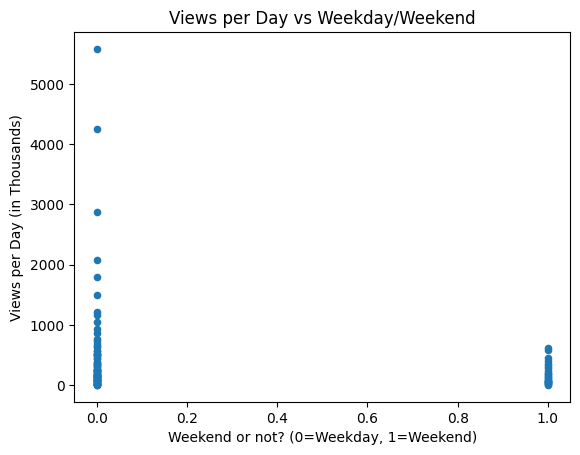

In [65]:
df.plot(kind='scatter',x='is_weekend',y='views_per_k')
plt.title('Views per Day vs Weekday/Weekend')
plt.xlabel('Weekend or not? (0=Weekday, 1=Weekend)')
plt.ylabel('Views per Day (in Thousands)')
plt.show()

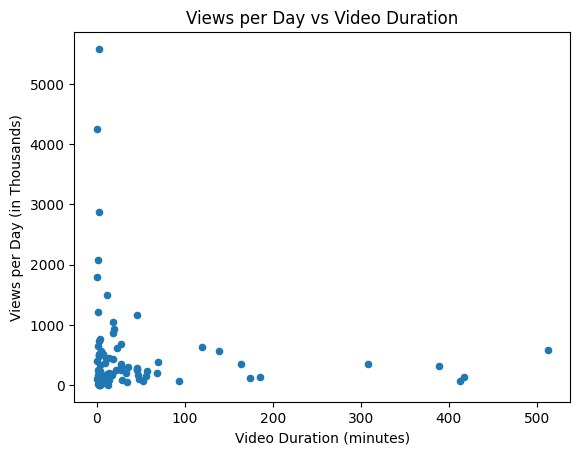

In [66]:
df.plot(kind='scatter',x='duration_parsed',y='views_per_k')
plt.title('Views per Day vs Video Duration')
plt.xlabel('Video Duration (minutes)')
plt.ylabel('Views per Day (in Thousands)')
plt.show()

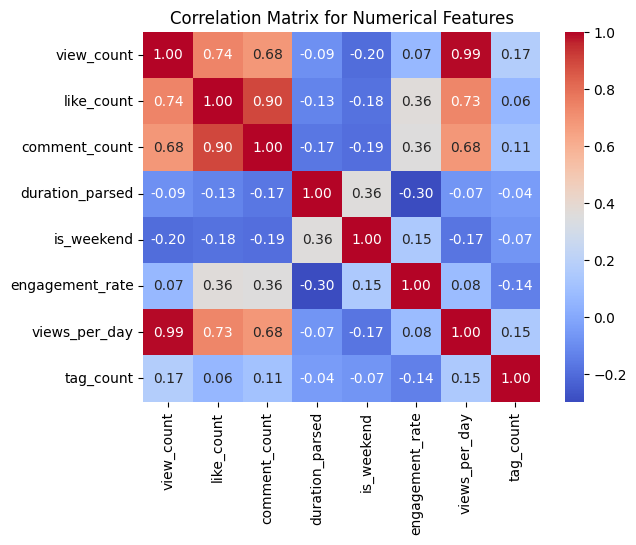

In [67]:
import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix for Numerical Features')
plt.show()

In [68]:
group = df.groupby("tag_count")["views_per_day"].mean().sort_values(ascending=False)
group_k = group / 1000
group_k = group_k.round(1).astype(str) + "K"
group_k.head(15)


tag_count
11    1620.2K
24    1454.1K
19    1362.2K
15    1219.9K
18    1017.6K
22     634.6K
34     613.4K
21     593.8K
40     509.1K
8      431.5K
25     352.4K
14     325.0K
6      315.8K
3      293.2K
1      287.6K
Name: views_per_day, dtype: object

In [69]:
df.groupby("channel_title")["views_per_day"].mean().sort_values().head(15)
 

channel_title
Motbb Vibes - Topic     2964.000000
Tonton Malele           4643.750000
LNRS - Topic            5982.636364
MOVIE BOT               7778.000000
SeanRiiVEVO            12348.333333
Frank Sinatra          12516.625000
Dean Martin            16180.750000
Crunchyroll            16741.000000
EllaFitzgeraldVEVO     18091.200000
Deevisions 🎥           24838.000000
Peysoh                 25547.000000
Chilleando Beats       33200.000000
AfinArte Music         39626.000000
Cartoon Universe       42518.000000
MexikoDro Beats        43870.000000
Name: views_per_day, dtype: float64